In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon
import ipympl 
%matplotlib widget
import matplotlib
import spatialdata as spd



/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Data Prep

In [2]:
# Directories
project_dir = Path("/Users/janzules/Roselab/Spatial/CAR_T")
data_dir    = project_dir / "data"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

In [3]:
# Files
hallmark_file  = project_dir / "code/references/Mouse_Hallmark.gmt"
zarr_file      = data_dir / "zarrFiles/CellCharterClusters"

## Loading Data

In [4]:
#Reading in files

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']


root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2645, 2706)
 - chunks =  ['3', '2645', '2706']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2348, 2448)
 - chunks =  ['3', '2348', '2448']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2445, 2505)
 - chunks =  ['3', '2445', '2505']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero

In [5]:
def read_gmt(gmt_path, min_genes=3, max_genes=5000):
    pathways = {}
    with open(gmt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0].replace("HALLMARK_", "").lower().capitalize()
            genes = [g for g in parts[2:] if g]  # parts[1] is "description"
            if min_genes <= len(genes) <= max_genes:
                pathways[name] = genes
    return pathways

pathways_dict = read_gmt(hallmark_file)

# Functions

In [ ]:
# Scoring Pathways of interest

def pathway_scoring(adata, pathways, pathways_of_interest):
    # Chcking if I named the pathways correctly
    failed_pathways = []
    for pathway_name in pathways_of_interest:
        if pathway_name not in pathways:
            print(f"Warning: Pathway '{pathway_name}' not found in the provided pathways.")
            failed_pathways.append(pathway_name)
            continue
    
        #Scoring pathways
        genes = pathways[pathway_name]
        
        genes_in_data = [gene for gene in genes if gene in adata.var_names]
        if len(genes_in_data) < 10: # the lowest number of genes in these pathways is around 27
            print(f"Warning: Not enough genes from pathway '{pathway_name}' are present in the data for scoring.")
            failed_pathways.append(pathway_name)
            continue
        
        sc.tl.score_genes(adata, 
                          gene_list=genes_in_data, 
                          score_name=pathway_name)
        if failed_pathways:
            print(f"Failed to score the following pathways: {', '.join(failed_pathways)}")

def find_pathway_names(pathways, search_term: list):
    matches = [key for key in pathways.keys() if any(term.lower() in key.lower() for term in search_term)]
    return matches




In [33]:
# For a given tissue, get its transform dynamically
from spatialdata.transformations import get_transformation
import numpy as np

def get_tissue_transform(sdata, tissue_name):
    """Returns (scale, tx, ty) for this tissue's shapes → image mapping."""
    shapes_key = f"{tissue_name}_cell_boundaries"
    tissue_image = f"{tissue_name}_hires_tissue_image"
    tf = get_transformation(sdata.shapes[tissue_image], get_all=True)
    # tf is dict: coord_system -> transform object
    cs = "downscale_to_hires"
    t = tf[cs]
    scale = float(t.scale[0])         # uniform scale
    tx, ty = float(t.translation[0]), float(t.translation[1])
    return scale, tx, ty

## Testing functions

In [34]:
get_tissue_transform(sdata, "RTCyPSCA_1_4")

KeyError: 'RTCyPSCA_1_4_hires_tissue_image'

# Scoring

In [ ]:
pathways = ['Glycolysis', 'Interferon_alpha_response']

pathway_scoring(adata, pathways_dict, pathways_of_interest=pathways)

# testing

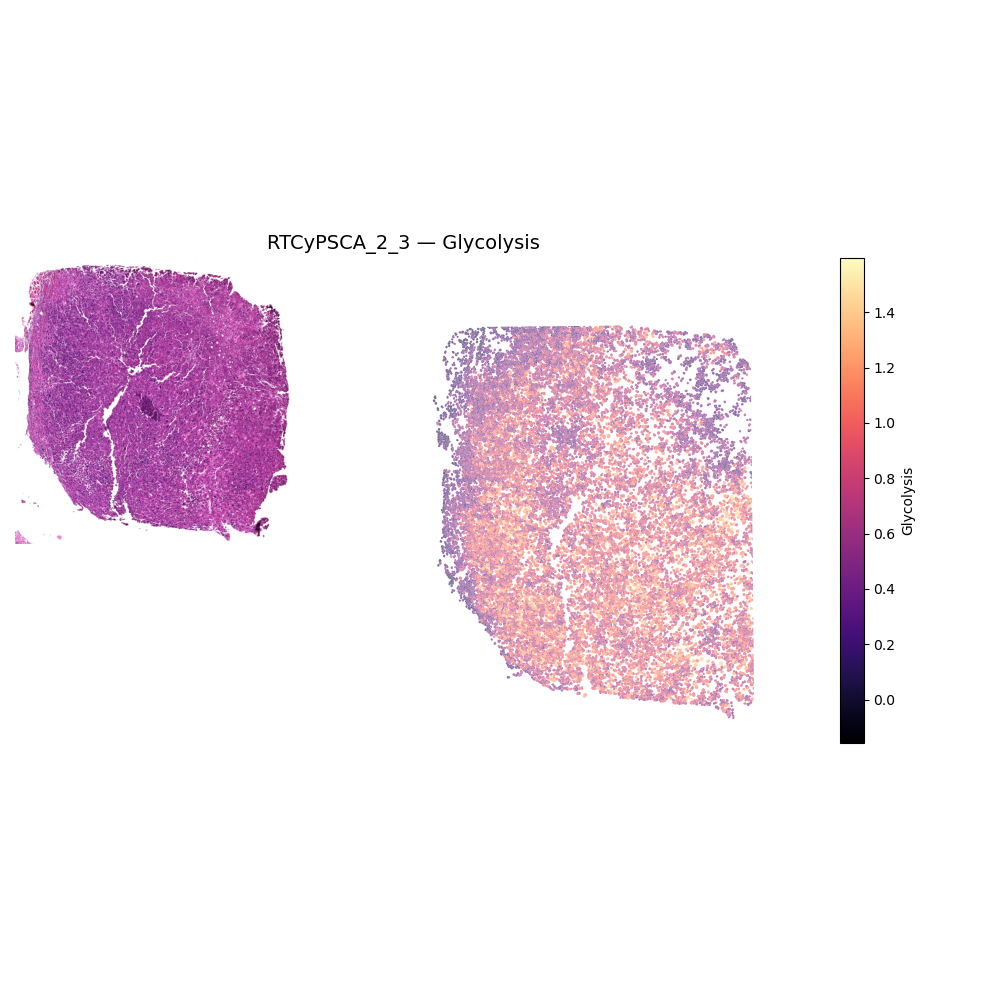

In [ ]:
tissue_name = "RTCyPSCA_2_3"
pathway_score = 'Glycolysis'
cmap = 'magma'


image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"
image    = sdata.images[image_key].values        # shape: (3, Y, X)
shapes   = sdata.shapes[boundary_key]     

# Su    # --- Subset adata to this tissue ---
mask   = adata.obs['tissue'] == tissue_name
a_sub  = adata[mask]
scores = a_sub.obs[pathway_score].values

# --- Merge scores into shapes (assuming index alignment) ---
shapes = shapes.join(a_sub.obs[[pathway_score]], how='left')
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

img_rgb = np.transpose(image, (1, 2, 0))
ax.imshow(img_rgb, origin="upper")

shapes.plot(
    column=pathway_score,
    cmap=cmap,
    ax=ax,
    alpha=0.6,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={"label": pathway_score, "shrink": 0.5}
)

ax.set_title(f"{tissue_name} — {pathway_score}", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

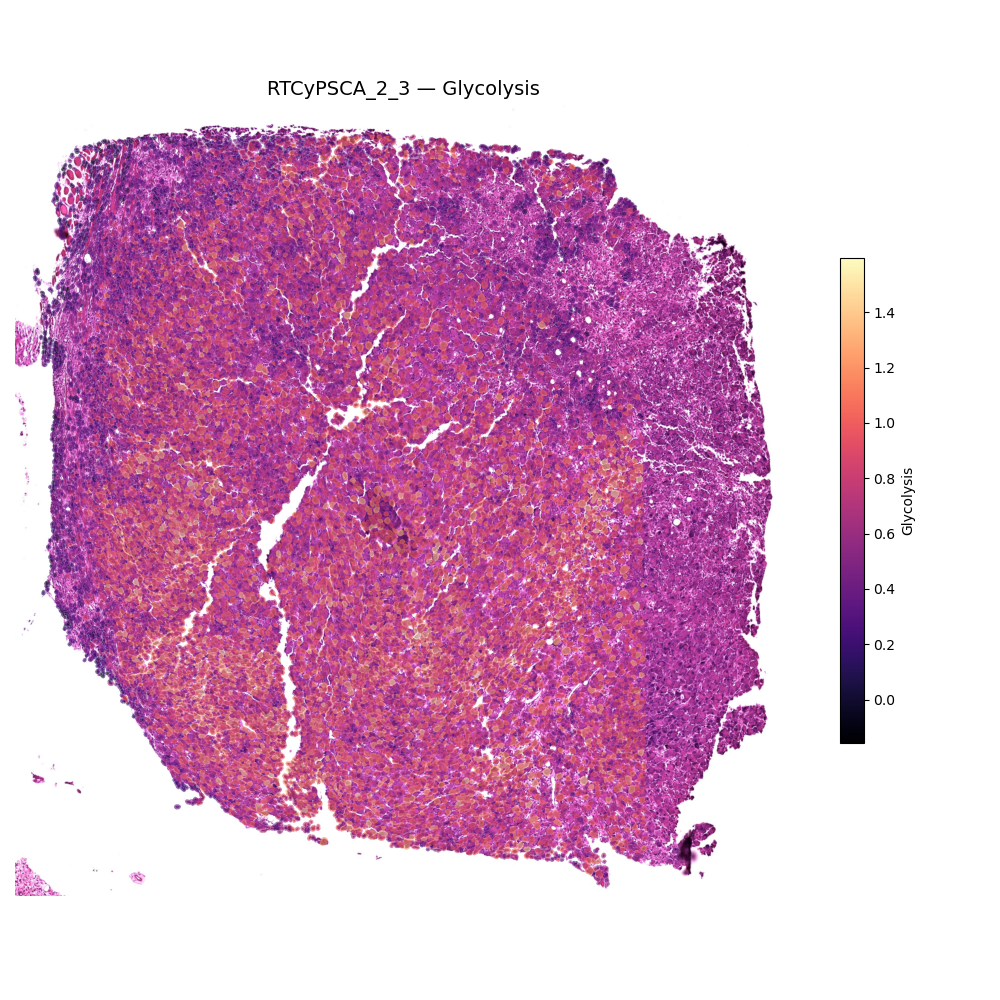

In [ ]:
from spatialdata.transformations import get_transformation
from shapely.affinity import scale as shapely_scale, translate
import geopandas as gpd

tissue_name   = "RTCyPSCA_2_3"
pathway_score = "Glycolysis"
cmap          = "magma"

image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"

image  = sdata.images[image_key].values  # (3, Y, X)
shapes = sdata.shapes[boundary_key].copy()

# --- Scale factor and translation from the transforms ---
scale_factor = 0.6917224
ty, tx       = 362.0, 2854.0   # translation in y, x

# --- Apply scale to polygons ---
shapes["geometry"] = shapes["geometry"].apply(
    lambda geom: shapely_scale(geom, xfact=scale_factor, yfact=scale_factor, origin=(0, 0))
)

# --- Merge scores ---
mask  = adata.obs['tissue'] == tissue_name
a_sub = adata[mask]
shapes = shapes.join(a_sub.obs[[pathway_score]], how="left")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

img_rgb = np.transpose(image, (1, 2, 0))

# Use extent to place image correctly accounting for translation
h, w = img_rgb.shape[:2]
ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper")

shapes.plot(
    column=pathway_score,
    cmap=cmap,
    ax=ax,
    alpha=0.6,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={"label": pathway_score, "shrink": 0.5}
)

ax.set_title(f"{tissue_name} — {pathway_score}", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
a_sub.shape

(19116, 19026)

In [ ]:
shapes.shape

(19117, 2)

In [ ]:
len(shapes)

19117

In [ ]:
scores

array([1.1165798 , 1.16541748, 0.40851565, ..., 0.81602441, 0.46153573,
       0.8713421 ], shape=(19116,))

In [ ]:
def plot_pathway_on_tissue(sdata, adata, tissue_name, pathway_score, cmap="magma"):
    """
    tissue_name   : e.g. 'RTCyPSCA_2_3'
    pathway_score : column name in adata.obs, e.g. 'Glycolysis'
    """
    # --- Pull image and shapes ---
    image_key    = f"{tissue_name}_hires_tissue_image"
    boundary_key = f"{tissue_name}_cell_boundaries"

    image    = sdata.images[image_key].values        # shape: (3, Y, X)
    shapes   = sdata.shapes[boundary_key]            # GeoDataFrame

    # --- Subset adata to this tissue ---
    mask   = adata.obs['tissue'] == tissue_name
    a_sub  = adata[mask]
    scores = a_sub.obs[pathway_score].values

    # --- Merge scores into shapes (assuming index alignment) ---
    shapes = shapes.copy()
    shapes[pathway_score] = scores

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # HnE image — transpose from (c, y, x) to (y, x, c)
    img_rgb = np.transpose(image, (1, 2, 0))
    ax.imshow(img_rgb, origin="upper")

    # Polygons colored by pathway score
    shapes.plot(
        column=pathway_score,
        cmap=cmap,
        ax=ax,
        alpha=0.6,
        legend=True,
        legend_kwds={"label": pathway_score, "shrink": 0.5}
    )

    ax.set_title(f"{tissue_name} — {pathway_score}", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Usage
plot_pathway_on_tissue(sdata, adata, 
                       tissue_name="RTCyPSCA_2_3", 
                       pathway_score="Glycolysis")

ValueError: Length of values (19116) does not match length of index (19117)

In [18]:
print(sdata.shapes['RTCyPSCA_2_3_cell_boundaries'].head())
print(adata[adata.obs['tissue'] == 'RTCyPSCA_2_3'].obs.head())

                                             cell_id  \
F08543_cellid_000006548-1  F08543_cellid_000006548-1   
F08543_cellid_000006549-1  F08543_cellid_000006549-1   
F08543_cellid_000006550-1  F08543_cellid_000006550-1   
F08543_cellid_000006551-1  F08543_cellid_000006551-1   
F08543_cellid_000006552-1  F08543_cellid_000006552-1   

                                                                    geometry  
F08543_cellid_000006548-1  POLYGON ((5799.1 3135.8, 5799.1 3133.9, 5793.3...  
F08543_cellid_000006549-1  POLYGON ((5358.7 2705.7, 5358.6 2703.8, 5354.8...  
F08543_cellid_000006550-1  POLYGON ((4823.5 1305.1, 4823.4 1299.3, 4821.5...  
F08543_cellid_000006551-1  POLYGON ((4622.2 3556.3, 4622.2 3554.3, 4620.2...  
F08543_cellid_000006552-1  POLYGON ((5255.2 1027.5, 5255.2 1025.6, 5253.2...  
                           sample                    cell_id  \
F08543_cellid_000006548-1  F08543  F08543_cellid_000006548-1   
F08543_cellid_000006549-1  F08543  F08543_cellid_000006549-1 

In [ ]:
missing = set(shapes.index) - set(a_sub.obs.index)

print(f"Missing indices in shapes: {missing}")

Missing indices in shapes: {'F08543_cellid_000014853-1'}


# Miscellaneous

## Metadata

In [20]:
list(sdata.images.keys())

['CyPSCA_1_1_hires_tissue_image',
 'CyPSCA_1_2_hires_tissue_image',
 'CyPSCA_2_4_hires_tissue_image',
 'CyT72_1_2_hires_tissue_image',
 'CyT72_1_4_hires_tissue_image',
 'CyT72_2_3_hires_tissue_image',
 'NoTx_1_4_hires_tissue_image',
 'NoTx_2_2_hires_tissue_image',
 'NoTx_2_4_hires_tissue_image',
 'RTCyPSCA_1_3_hires_tissue_image',
 'RTCyPSCA_1_4_hires_tissue_image',
 'RTCyPSCA_2_3_hires_tissue_image',
 'RTCyPSCA_2_4_hires_tissue_image',
 'RTCyT72_1_1_hires_tissue_image',
 'RTCyT72_2_1_hires_tissue_image',
 'RTCyT72_2_4_hires_tissue_image']

In [24]:
from spatialdata.transformations import get_transformation

for image_key in sdata.images:
    transforms = get_transformation(sdata.images[image_key], get_all=True)
    for cs, t in transforms.items():
        matrix = t.to_affine_matrix(input_axes=('x', 'y'), output_axes=('x', 'y'))
        x = matrix[0, 2]
        y = matrix[1, 2]
        print(f"{image_key} [{cs}]: x={x:.2f}, y={y:.2f}")
        

CyPSCA_1_1_hires_tissue_image [downscale_to_hires]: x=210.00, y=125.00
CyPSCA_1_2_hires_tissue_image [downscale_to_hires]: x=1205.00, y=304.00
CyPSCA_2_4_hires_tissue_image [downscale_to_hires]: x=3274.00, y=2978.00
CyT72_1_2_hires_tissue_image [downscale_to_hires]: x=156.00, y=582.00
CyT72_1_4_hires_tissue_image [downscale_to_hires]: x=858.00, y=2888.00
CyT72_2_3_hires_tissue_image [downscale_to_hires]: x=140.00, y=473.00
NoTx_1_4_hires_tissue_image [downscale_to_hires]: x=415.00, y=3031.00
NoTx_2_2_hires_tissue_image [downscale_to_hires]: x=299.00, y=2879.00
NoTx_2_4_hires_tissue_image [downscale_to_hires]: x=212.00, y=2729.00
RTCyPSCA_1_3_hires_tissue_image [downscale_to_hires]: x=2419.00, y=542.00
RTCyPSCA_1_4_hires_tissue_image [downscale_to_hires]: x=2909.00, y=218.00
RTCyPSCA_2_3_hires_tissue_image [downscale_to_hires]: x=2854.00, y=362.00
RTCyPSCA_2_4_hires_tissue_image [downscale_to_hires]: x=3116.00, y=1075.00
RTCyT72_1_1_hires_tissue_image [downscale_to_hires]: x=2739.00, y=

In [ ]:
from spatialdata.transformations import get_transformation

# Check what transforms are stored
print(get_transformation(sdata.images[image_key], get_all=True))
print(get_transformation(sdata.shapes[boundary_key], get_all=True))

sdata

{'downscale_to_hires': Sequence 
    Translation (c, y, x)
        [   0.  362. 2854.]
    Identity }
{'downscale_to_hires': Scale (x, y)
    [0.6917224 0.6917224]}


In [9]:
sdata.tables['segmentation_counts'].obsm['spatial'].shape

(425859, 2)